# 02 · Delivery readiness

Which regions experience longer or late deliveries, where fulfilment attention should go, and what would shorten delivery.

In [1]:
import sys, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "..")            # analysis/warehouse.py
from warehouse import get_engine, query, table
engine = get_engine()               # SQLAlchemy engine: DuckDB by default, BigQuery with WAREHOUSE=bigquery
pd.set_option("display.float_format", "{:,.2f}".format)
print(engine.url)

duckdb:////home/claude/olist-data-platform/data/warehouse/olist.duckdb


In [2]:
dp = table("delivery_performance_by_state", engine).sort_values("avg_delivery_days", ascending=False)
dp.round(2)

,customer_state,delivered_orders,avg_delivery_days,avg_estimated_days,late_rate,avg_days_late_when_late,avg_seller_handling_days,avg_carrier_transit_days,avg_freight_value,avg_review_score
8,RR,41,29.34,46.63,0.12,36.40,3.22,25.61,48.34,3.90
20,AP,67,27.18,46.87,0.04,48.33,2.75,23.72,41.30,4.24
26,AM,145,26.36,45.92,0.04,20.17,2.44,23.44,37.45,4.24
24,AL,397,24.50,33.21,0.24,8.54,2.88,21.07,38.58,3.85
17,PA,946,23.73,37.79,0.12,11.62,2.86,20.26,39.70,3.91
22,MA,717,21.51,31.08,0.20,9.31,2.89,17.94,42.95,3.83
13,SE,335,21.46,31.48,0.15,16.20,3.06,17.89,40.94,3.91
11,CE,1279,21.20,32.00,0.15,13.63,2.78,17.89,36.50,3.94
25,AC,80,21.00,41.72,0.04,18.67,2.78,17.51,45.55,4.09
15,PB,517,20.39,33.65,0.11,9.79,2.83,16.91,48.84,4.08


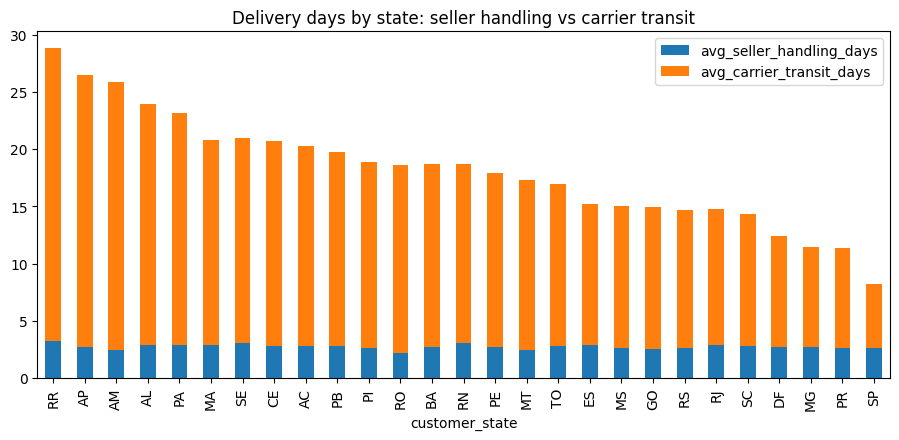

In [3]:
ax = dp.set_index("customer_state")[["avg_seller_handling_days","avg_carrier_transit_days"]].plot.bar(stacked=True, figsize=(11,4.5), title="Delivery days by state: seller handling vs carrier transit")

Seller handling is ~2.7 days in every state; the whole regional gap (SP 9 days vs RR/AP/AM 26-29 days) is the carrier leg. Fulfilment attention therefore belongs in carrier contracts and regional hubs for the North/North-East, not in seller processes.

In [4]:
query('''
select is_late, count(*) orders, avg(review_score) avg_review, avg(delivery_delay_days) avg_delay_days
from olist_analytics.fact_orders
where order_status='delivered' and delivered_to_customer_at is not null and review_score is not null
group by 1''', engine)

,is_late,orders,avg_review,avg_delay_days
0,False,88163,4.29,-13.71
1,True,7661,2.57,8.76


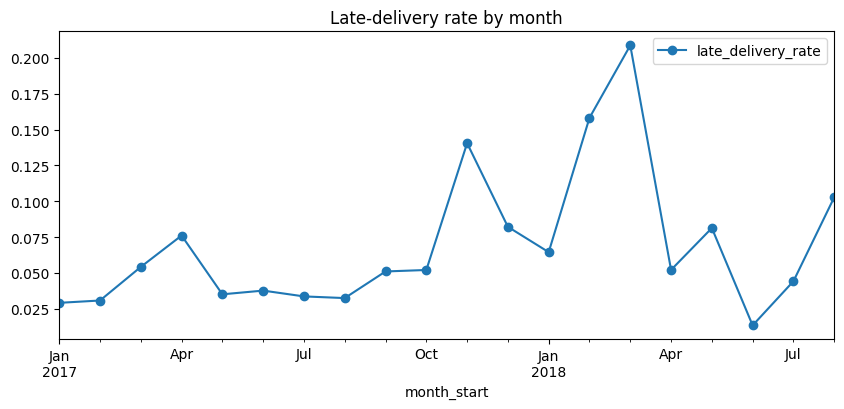

In [5]:
ml = table("monthly_sales", engine).sort_values("month_start")
ml = ml[(ml.month_start >= "2017-01-01") & (ml.month_start <= "2018-08-01")]
ax = ml.plot(x="month_start", y="late_delivery_rate", marker="o", figsize=(10,4), title="Late-delivery rate by month")

Late rate spikes when volume spikes (Nov 2017 and Feb-Mar 2018), pointing at carrier capacity rather than distance. The promised date is also very generous (est. 24 days vs 12.5 actual), so the 8% late rate reflects real carrier failures.

In [6]:
query('''
select customer_state, count(*) orders, avg(actual_delivery_days) avg_days, avg(freight_value) avg_freight,
       avg(case when is_late then 1.0 else 0.0 end) late_rate
from olist_analytics.fact_orders
where order_status='delivered' and delivered_to_customer_at is not null
group by 1 order by late_rate desc limit 8''', engine)

,customer_state,orders,avg_days,avg_freight,late_rate
0,AL,397,24.50,38.58,0.24
1,MA,717,21.51,42.95,0.20
2,PI,476,19.39,42.98,0.16
3,CE,1279,21.20,36.50,0.15
4,SE,335,21.46,40.94,0.15
5,BA,3256,19.28,29.96,0.14
6,RJ,12350,15.24,23.95,0.13
7,TO,274,17.60,42.35,0.13
